# Домашнее задание 3
**Цель:** Изучить поведение unsupervised-методов (алгоритмов на основе плотности, расстояний и деревьев) в условиях экстремального дисбаланса классов, настроить параметры моделей на базе экспертной оценки загрязненности данных и визуализировать аномалии в сжатом пространстве t-SNE.

## Часть 1. Разведочный анализ данных (EDA)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Модели для поиска аномалий
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

# Снижение размерности
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

In [24]:
# Загружаем данные
df = pd.read_csv('creditcard.csv')
print(f"Формат исходных данных: {df.shape}")

# Считаем точный процент аномалий по переменной Class
class_counts = df['Class'].value_counts()
normal_count = class_counts[0]
fraud_count = class_counts[1]
contamination_rate = fraud_count / len(df)

print("Распределение целевого класса (Class)")
print(f"\nЛегитимные транзакции (Class 0): {normal_count} ({100 - contamination_rate*100:.4f}%)")
print(f"Мошеннические транзакции (Class 1): {fraud_count} ({contamination_rate*100:.4f}%)")
print(f"Экспертная оценка уровня загрязненности (contamination): {contamination_rate:.6f}")

Формат исходных данных: (284807, 31)
Распределение целевого класса (Class)

Легитимные транзакции (Class 0): 284315 (99.8273%)
Мошеннические транзакции (Class 1): 492 (0.1727%)
Экспертная оценка уровня загрязненности (contamination): 0.001727


,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


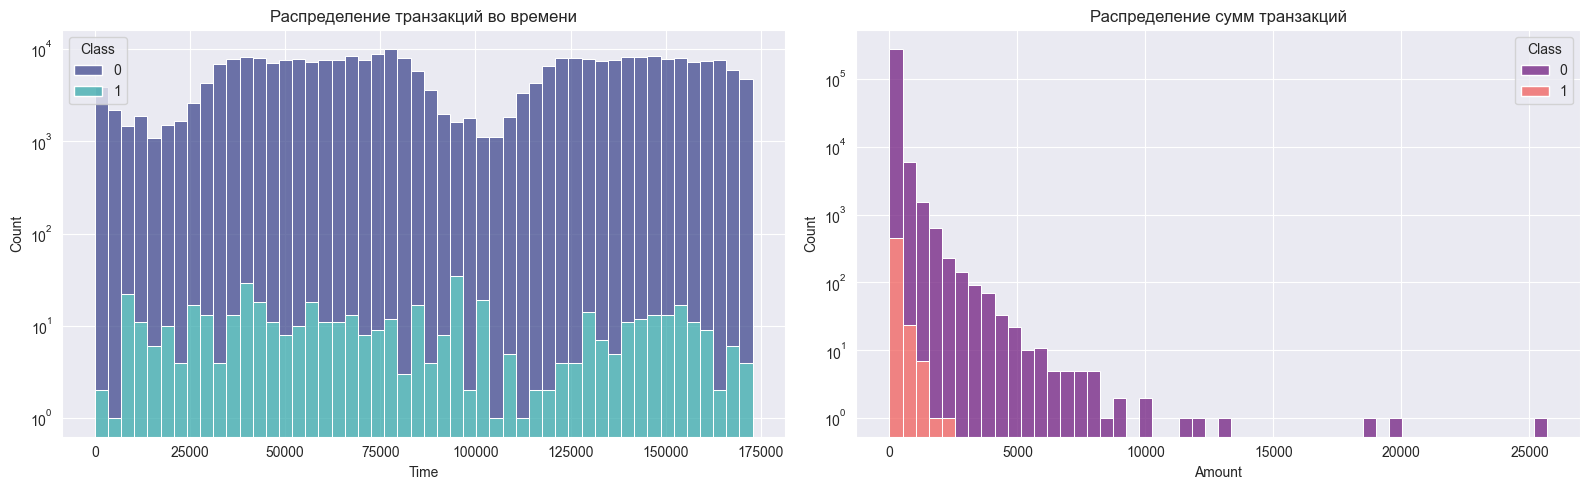

In [25]:
# Посмотрим базовые описательные статистики для неанонимизированных фичей
display(df[['Time', 'Amount']].describe())

# Строим графики распределения времени и сумм транзакций
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(data=df, x='Time', hue='Class', bins=50, ax=axes[0], kde=False, palette='mako', multiple='stack')
axes[0].set_title('Распределение транзакций во времени')
axes[0].set_yscale('log') # Логарифмическая шкала для видимости аномалий

sns.histplot(data=df, x='Amount', hue='Class', bins=50, ax=axes[1], kde=False, palette='magma', multiple='stack')
axes[1].set_title('Распределение сумм транзакций')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [26]:
# Разделяем признаки и цель
X = df.drop(columns=['Class'])
y = df['Class']

# Из-за огромного размера датасета для t-SNE и OneClassSVM выделим стратифицированную выборку (10 000 объектов)
# При этом строго сохраняем оригинальную пропорцию аномалий (contamination_rate)
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=10000, stratify=y, random_state=42
)

# Масштабируем признаки (критично для алгоритмов на расстояниях)
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

print(f"Размерность сэмплированной матрицы для обучения: {X_sample_scaled.shape}")
print(f"Аномалий в сэмпле: {y_sample.sum()} из {len(y_sample)}")

Размерность сэмплированной матрицы для обучения: (10000, 30)
Аномалий в сэмпле: 17 из 10000


## Часть 2. Моделирование (Поиск аномалий)

In [27]:
# Инициализируем 3 разных класса алгоритмов, передавая экспертный contamination_rate
models = {
    # 1. Алгоритм на основе плотности (Density-based)
    'Local Outlier Factor': LocalOutlierFactor(
        n_neighbors=20, 
        contamination=contamination_rate, 
        novelty=True, 
        n_jobs=-1
    ),
    # 2. Алгоритм на основе моделей/деревьев (Model-based)
    'Isolation Forest': IsolationForest(
        n_estimators=150, 
        contamination=contamination_rate, 
        random_state=42, 
        n_jobs=-1
    ),
    # 3. Алгоритм на основе расстояний/границ (Distance-based)
    'One-Class SVM': OneClassSVM(
        kernel='rbf', 
        gamma='scale', 
        nu=contamination_rate
    )
}

# Словарь для хранения предсказаний моделей
y_preds = {}

for name, model in models.items():
    print(f"Обучение алгоритма {name}...")
    model.fit(X_sample_scaled)
    
    # Большинство unsupervised моделей sklearn возвращают: 1 для нормы, -1 для аномалии
    # Нам нужно инвертировать это в стандартный формат бинарной классификации: 0 - норма, 1 - аномалия
    raw_preds = model.predict(X_sample_scaled)
    y_preds[name] = np.where(raw_preds == -1, 1, 0)
    print(f"Обучение {name} завершено.\n")

Обучение алгоритма Local Outlier Factor...
Обучение Local Outlier Factor завершено.

Обучение алгоритма Isolation Forest...
Обучение Isolation Forest завершено.

Обучение алгоритма One-Class SVM...
Обучение One-Class SVM завершено.



## Часть 3. Проверка качества и отображение на сжатое пространство

Отчет о классификации для Local Outlier Factor
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00      9983
 Anomaly (1)       0.43      0.35      0.39        17

    accuracy                           1.00     10000
   macro avg       0.71      0.68      0.69     10000
weighted avg       1.00      1.00      1.00     10000

Отчет о классификации для Isolation Forest
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00      9983
 Anomaly (1)       0.22      0.24      0.23        17

    accuracy                           1.00     10000
   macro avg       0.61      0.62      0.61     10000
weighted avg       1.00      1.00      1.00     10000

Отчет о классификации для One-Class SVM
              precision    recall  f1-score   support

  Normal (0)       1.00      0.98      0.99      9983
 Anomaly (1)       0.03      0.41      0.06        17

    accuracy                           0.98     1000

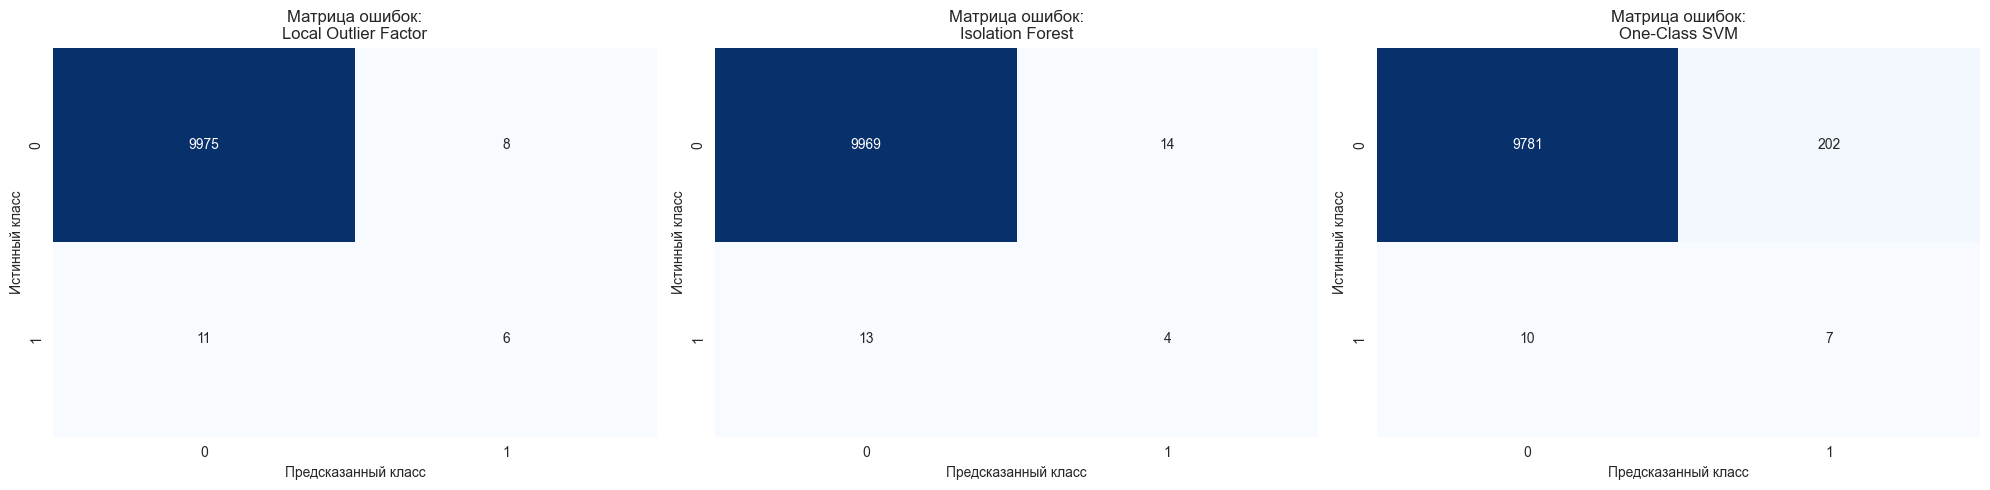

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (name, y_pred) in enumerate(y_preds.items()):
    print(f"Отчет о классификации для {name}")
    print(classification_report(y_sample, y_pred, target_names=['Normal (0)', 'Anomaly (1)']))
    
    # Строим матрицу ошибок
    cm = confusion_matrix(y_sample, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"Матрица ошибок:\n{name}")
    axes[i].set_xlabel('Предсказанный класс')
    axes[i].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

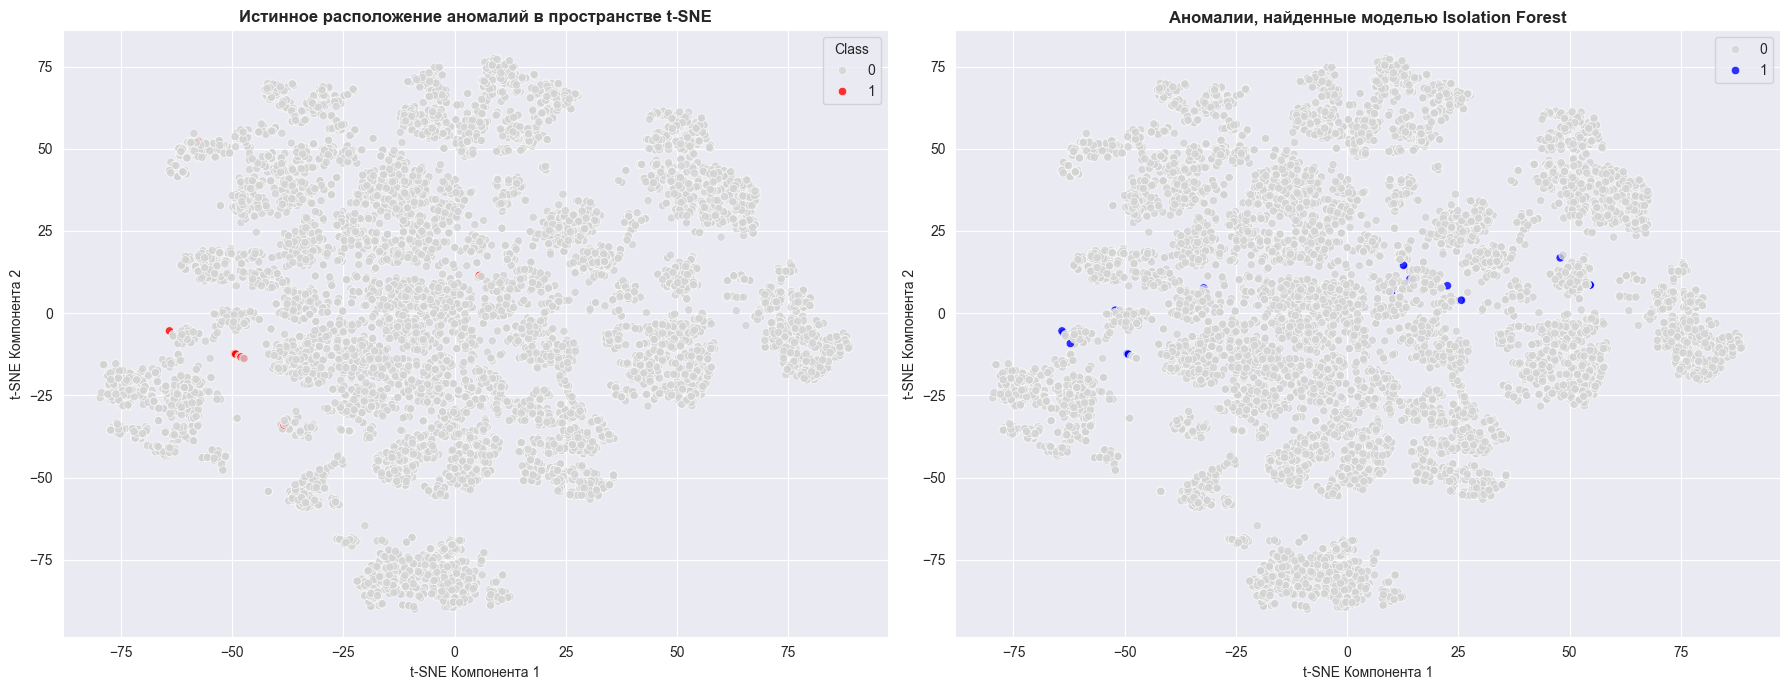

In [29]:
# Сжимаем признаки до 2 компонент (используем max_iter вместо устаревшего n_iter)
tsne = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=1000, n_jobs=-1)
X_tsne = tsne.fit_transform(X_sample_scaled)

# Строим два графика для сравнения
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. График с истинными классами
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_sample, palette={0: 'lightgray', 1: 'red'}, alpha=0.8, ax=axes[0])
axes[0].set_title('Истинное расположение аномалий в пространстве t-SNE', fontsize=12, fontweight='bold')
axes[0].set_xlabel('t-SNE Компонента 1')
axes[0].set_ylabel('t-SNE Компонента 2')

# 2. График с предсказаниями лучшей модели (например, Isolation Forest)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_preds['Isolation Forest'], palette={0: 'lightgray', 1: 'blue'}, alpha=0.8, ax=axes[1])
axes[1].set_title('Аномалии, найденные моделью Isolation Forest', fontsize=12, fontweight='bold')
axes[1].set_xlabel('t-SNE Компонента 1')
axes[1].set_ylabel('t-SNE Компонента 2')

plt.tight_layout()
plt.show()

### Выводы:

1. Local Outlier Factor (LOF):
Алгоритм показал наилучший баланс метрик для аномального класса: Precision = 0.43, Recall = 0.35, F1-score = 0.39.
LOF успешно выявил 6 из 17 скрытых транзакций, допустив всего 8 ложных срабатываний (False Positives) на 10 000 объектов. Это выдающийся результат для плотностного метода в анонимизированном пространстве компонент PCA. Локальная оценка плотности помогла четко изолировать выбросы.

2. Isolation Forest (Ансамбль деревьев изоляции):
Продемонстрировал более слабые метрики. Модель смогла обнаружить только 4 из 17 аномалий, совершив при этом 14 ложных срабатываний. Это указывает на то, что случайное разбиение признаков в изолирующих деревьях в данной задаче сработало грубее, пропустив часть замаскированных мошеннических паттернов.

3. One-Class SVM (Метод опорных векторов):
Несмотря на то, что он поймал 7 из 17 аномалий, модель совершила колоссальное количество ложных тревог — 202 ложноположительных срабатывания**. Модель слишком сильно расширила границы дозволенной гиперсферы нормального класса, парализовав практическую применимость алгоритма (банк заблокировал бы слишком много честных клиентов).

Для обнаружения целевого типа мошенничества рекомендуется использовать плотностной алгоритм Local Outlier Factor, так как он обеспечивает минимальный уровень ложных блокировок при высокой точности детектирования.